In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import GroupShuffleSplit

from scipy.io import loadmat

In [2]:
PROJECT_ROOT = Path(
    r"C:\Users\armaa\OneDrive\Desktop\TinyML-Vibration-Anomaly-Detection"
)

RAW_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "CWRU"
)

PROCESSED_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "CWRU"
)

WINDOW_PATH = (
    PROCESSED_PATH
    / "windows"
)

WINDOW_PATH.mkdir(
    parents=True,
    exist_ok=True
)

print("Project:", PROJECT_ROOT)
print("Raw:", RAW_PATH)
print("Processed:", PROCESSED_PATH)
print("Windows:", WINDOW_PATH)

Project: C:\Users\armaa\OneDrive\Desktop\TinyML-Vibration-Anomaly-Detection
Raw: C:\Users\armaa\OneDrive\Desktop\TinyML-Vibration-Anomaly-Detection\data\raw\CWRU
Processed: C:\Users\armaa\OneDrive\Desktop\TinyML-Vibration-Anomaly-Detection\data\processed\CWRU
Windows: C:\Users\armaa\OneDrive\Desktop\TinyML-Vibration-Anomaly-Detection\data\processed\CWRU\windows


In [3]:
metadata_file = (
    WINDOW_PATH
    / "cwru_window_metadata.csv"
)

window_df = pd.read_csv(
    metadata_file
)

print(
    "Metadata shape:",
    window_df.shape
)

display(
    window_df.head()
)

Metadata shape: (583, 7)


,recording_id,source_file,signal_id,class,window_id,start_sample,end_sample
0,B007_0_X118,B007_0.mat,X118,Ball,0,0,12000
1,B007_0_X118,B007_0.mat,X118,Ball,1,6000,18000
2,B007_0_X118,B007_0.mat,X118,Ball,2,12000,24000
3,B007_0_X118,B007_0.mat,X118,Ball,3,18000,30000
4,B007_0_X118,B007_0.mat,X118,Ball,4,24000,36000


In [4]:
recordings = (
    window_df[
        [
            "recording_id",
            "class"
        ]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

print(
    "Unique recordings:",
    len(recordings)
)

display(
    recordings.sort_values(
        "recording_id"
    )
)

Unique recordings: 17


,recording_id,class
0,B007_0_X118,Ball
1,B007_1_X119,Ball
2,B007_2_X120,Ball
3,B007_3_X121,Ball
4,IR007_0_X105,Inner Race
5,IR007_1_X106,Inner Race
6,IR007_2_X107,Inner Race
7,IR007_3_X108,Inner Race
8,NORMAL_0_X097,Healthy
9,NORMAL_1_X098,Healthy


In [5]:
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(
        window_df,
        groups=window_df[
            "recording_id"
        ]
    )
)

In [6]:
train_df = window_df.iloc[
    train_idx
].copy()

test_df = window_df.iloc[
    test_idx
].copy()

print(
    "Train windows:",
    len(train_df)
)

print(
    "Test windows:",
    len(test_df)
)

Train windows: 507
Test windows: 76


In [7]:
print(
    "Train recordings:",
    train_df[
        "recording_id"
    ].nunique()
)

print(
    "Test recordings:",
    test_df[
        "recording_id"
    ].nunique()
)

Train recordings: 13
Test recordings: 4


In [8]:
train_groups = set(
    train_df[
        "recording_id"
    ]
)

test_groups = set(
    test_df[
        "recording_id"
    ]
)

print(
    "Train/Test overlap:",
    train_groups & test_groups
)

Train/Test overlap: set()


In [9]:
gss_val = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx2, val_idx = next(
    gss_val.split(
        train_df,
        groups=train_df[
            "recording_id"
        ]
    )
)

In [10]:
final_train_df = train_df.iloc[
    train_idx2
].copy()

val_df = train_df.iloc[
    val_idx
].copy()

print(
    "Final train windows:",
    len(final_train_df)
)

print(
    "Validation windows:",
    len(val_df)
)

print(
    "Test windows:",
    len(test_df)
)

Final train windows: 390
Validation windows: 117
Test windows: 76


In [11]:
print(
    "TRAIN recordings:",
    final_train_df[
        "recording_id"
    ].nunique()
)

print(
    "VALIDATION recordings:",
    val_df[
        "recording_id"
    ].nunique()
)

print(
    "TEST recordings:",
    test_df[
        "recording_id"
    ].nunique()
)

TRAIN recordings: 10
VALIDATION recordings: 3
TEST recordings: 4


In [12]:
print("TRAIN")
print(
    final_train_df[
        "class"
    ].value_counts()
)

print("\nVALIDATION")
print(
    val_df[
        "class"
    ].value_counts()
)

print("\nTEST")
print(
    test_df[
        "class"
    ].value_counts()
)

TRAIN
class
Healthy       276
Inner Race     57
Outer Race     38
Ball           19
Name: count, dtype: int64

VALIDATION
class
Healthy       79
Ball          19
Outer Race    19
Name: count, dtype: int64

TEST
class
Ball          38
Inner Race    19
Outer Race    19
Name: count, dtype: int64


In [14]:
train_groups = set(
    final_train_df[
        "recording_id"
    ]
)

val_groups = set(
    val_df[
        "recording_id"
    ]
)

test_groups = set(
    test_df[
        "recording_id"
    ]
)

print(
    "Train/Validation:",
    train_groups & val_groups
)

print(
    "Train/Test:",
    train_groups & test_groups
)

print(
    "Validation/Test:",
    val_groups & test_groups
)

Train/Validation: set()
Train/Test: set()
Validation/Test: set()


In [15]:
train_recordings = (
    final_train_df[
        [
            "recording_id",
            "class"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        "recording_id"
    )
)

val_recordings = (
    val_df[
        [
            "recording_id",
            "class"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        "recording_id"
    )
)

test_recordings = (
    test_df[
        [
            "recording_id",
            "class"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        "recording_id"
    )
)

print("TRAIN RECORDINGS")
display(train_recordings)

print("VALIDATION RECORDINGS")
display(val_recordings)

print("TEST RECORDINGS")
display(test_recordings)

TRAIN RECORDINGS


,recording_id,class
57,B007_3_X121,Ball
76,IR007_0_X105,Inner Race
114,IR007_2_X107,Inner Race
133,IR007_3_X108,Inner Race
152,NORMAL_0_X097,Healthy
191,NORMAL_1_X098,Healthy
270,NORMAL_2_X098,Healthy
349,NORMAL_2_X099,Healthy
507,OR007@6_0_X130,Outer Race
564,OR007@6_3_X133,Outer Race


VALIDATION RECORDINGS


,recording_id,class
38,B007_2_X120,Ball
428,NORMAL_3_X100,Healthy
526,OR007@6_1_X131,Outer Race


TEST RECORDINGS


,recording_id,class
0,B007_0_X118,Ball
19,B007_1_X119,Ball
95,IR007_1_X106,Inner Race
545,OR007@6_2_X132,Outer Race


In [16]:
final_train_df.to_csv(
    WINDOW_PATH
    / "train_metadata.csv",
    index=False
)

val_df.to_csv(
    WINDOW_PATH
    / "validation_metadata.csv",
    index=False
)

test_df.to_csv(
    WINDOW_PATH
    / "test_metadata.csv",
    index=False
)

print(
    "Split metadata saved."
)

Split metadata saved.


In [17]:
split_records = []

for split_name, df in [
    ("Train", final_train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:

    records = (
        df[
            [
                "recording_id",
                "class"
            ]
        ]
        .drop_duplicates()
    )

    for _, row in records.iterrows():

        split_records.append({
            "split": split_name,
            "recording_id":
                row["recording_id"],
            "class":
                row["class"]
        })

split_assignment_df = pd.DataFrame(
    split_records
)

display(
    split_assignment_df
)

,split,recording_id,class
0,Train,B007_3_X121,Ball
1,Train,IR007_0_X105,Inner Race
2,Train,IR007_2_X107,Inner Race
3,Train,IR007_3_X108,Inner Race
4,Train,NORMAL_0_X097,Healthy
5,Train,NORMAL_1_X098,Healthy
6,Train,NORMAL_2_X098,Healthy
7,Train,NORMAL_2_X099,Healthy
8,Train,OR007@6_0_X130,Outer Race
9,Train,OR007@6_3_X133,Outer Race


In [18]:
split_assignment_df.to_csv(
    WINDOW_PATH
    / "recording_split_assignment.csv",
    index=False
)

In [19]:
split_summary = pd.DataFrame({

    "Split": [
        "Train",
        "Validation",
        "Test"
    ],

    "Recordings": [
        final_train_df[
            "recording_id"
        ].nunique(),

        val_df[
            "recording_id"
        ].nunique(),

        test_df[
            "recording_id"
        ].nunique()
    ],

    "Windows": [
        len(final_train_df),
        len(val_df),
        len(test_df)
    ]
})

display(
    split_summary
)

,Split,Recordings,Windows
0,Train,10,390
1,Validation,3,117
2,Test,4,76


In [20]:
split_summary.to_csv(
    WINDOW_PATH
    / "split_summary.csv",
    index=False
)

In [21]:
required_columns = [
    "recording_id",
    "source_file",
    "signal_id",
    "class",
    "window_id",
    "start_sample",
    "end_sample"
]

missing_columns = [
    col
    for col in required_columns
    if col not in window_df.columns
]

print(
    "Missing columns:",
    missing_columns
)

Missing columns: []


In [22]:
TRAIN_PATH = (
    WINDOW_PATH / "train"
)

VAL_PATH = (
    WINDOW_PATH / "validation"
)

TEST_PATH = (
    WINDOW_PATH / "test"
)

TRAIN_PATH.mkdir(
    parents=True,
    exist_ok=True
)

VAL_PATH.mkdir(
    parents=True,
    exist_ok=True
)

TEST_PATH.mkdir(
    parents=True,
    exist_ok=True
)

print(
    "Window folders created."
)

Window folders created.


In [23]:
def save_windows(
    metadata_df,
    output_path
):

    saved_count = 0

    for _, row in metadata_df.iterrows():

        source_path = (
            RAW_PATH
            / row["source_file"]
        )

        data = loadmat(
            source_path
        )

        signal_key = (
            row["signal_id"]
            + "_DE_time"
        )

        signal = np.asarray(
            data[signal_key]
        ).squeeze()

        start = int(
            row["start_sample"]
        )

        end = int(
            row["end_sample"]
        )

        window = signal[
            start:end
        ]

        if len(window) != 12000:

            print(
                "Invalid window:",
                row["recording_id"],
                row["window_id"]
            )

            continue

        filename = (
            row["recording_id"]
            + "_window_"
            + str(
                row["window_id"]
            ).zfill(4)
            + ".npy"
        )

        np.save(
            output_path / filename,
            window
        )

        saved_count += 1

    return saved_count

In [24]:
train_saved = save_windows(
    final_train_df,
    TRAIN_PATH
)

print(
    "Training windows saved:",
    train_saved
)

Training windows saved: 390


In [25]:
val_saved = save_windows(
    val_df,
    VAL_PATH
)

print(
    "Validation windows saved:",
    val_saved
)

Validation windows saved: 117


In [26]:
test_saved = save_windows(
    test_df,
    TEST_PATH
)

print(
    "Test windows saved:",
    test_saved
)

Test windows saved: 76


In [27]:
train_files = list(
    TRAIN_PATH.glob("*.npy")
)

val_files = list(
    VAL_PATH.glob("*.npy")
)

test_files = list(
    TEST_PATH.glob("*.npy")
)

print(
    "Train files:",
    len(train_files)
)

print(
    "Validation files:",
    len(val_files)
)

print(
    "Test files:",
    len(test_files)
)

Train files: 390
Validation files: 117
Test files: 76


In [28]:
sample_file = train_files[0]

sample_window = np.load(
    sample_file
)

print(
    "File:",
    sample_file.name
)

print(
    "Shape:",
    sample_window.shape
)

print(
    "Data type:",
    sample_window.dtype
)

File: B007_3_X121_window_0000.npy
Shape: (12000,)
Data type: float64


In [31]:
duration = (
    len(sample_window)
    / 12000
)

print(
    "Duration:",
    duration,
    "seconds"
)

Duration: 1.0 seconds


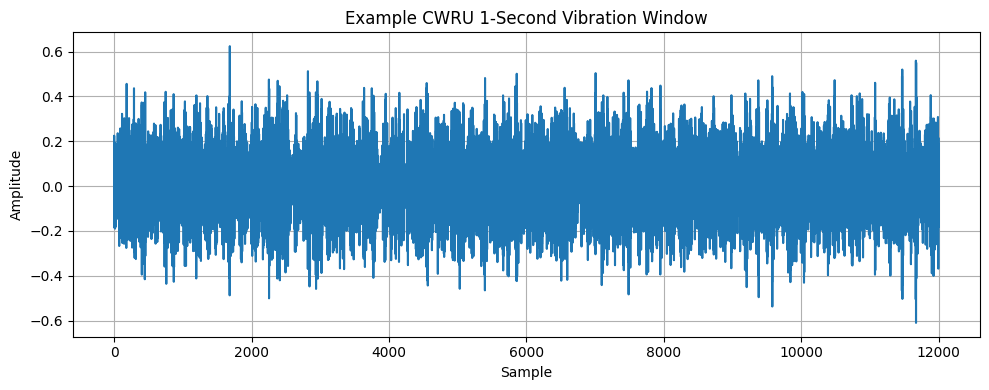

In [32]:
plt.figure(
    figsize=(10, 4)
)

plt.plot(
    sample_window
)

plt.title(
    "Example CWRU 1-Second Vibration Window"
)

plt.xlabel(
    "Sample"
)

plt.ylabel(
    "Amplitude"
)

plt.grid()

plt.tight_layout()

plt.show()

In [33]:
print(
    sample_file.name
)

B007_3_X121_window_0000.npy


In [34]:
assert train_groups.isdisjoint(
    val_groups
)

assert train_groups.isdisjoint(
    test_groups
)

assert val_groups.isdisjoint(
    test_groups
)

print(
    "PASS: No recording-level leakage."
)

PASS: No recording-level leakage.


In [35]:
print(
    "========== CWRU DATASET =========="
)

print(
    "Sampling frequency:",
    12000,
    "Hz"
)

print(
    "Window duration:",
    1,
    "second"
)

print(
    "Samples per window:",
    12000
)

print(
    "Overlap:",
    50,
    "%"
)

print(
    "Original recordings:",
    window_df[
        "recording_id"
    ].nunique()
)

print(
    "Total windows:",
    len(window_df)
)

print(
    "Train windows:",
    len(final_train_df)
)

print(
    "Validation windows:",
    len(val_df)
)

print(
    "Test windows:",
    len(test_df)
)

========== CWRU DATASET ==========
Sampling frequency: 12000 Hz
Window duration: 1 second
Samples per window: 12000
Overlap: 50 %
Original recordings: 17
Total windows: 583
Train windows: 390
Validation windows: 117
Test windows: 76


In [36]:
dataset_config = pd.DataFrame([{

    "sampling_frequency_hz": 12000,

    "window_duration_seconds": 1,

    "window_samples": 12000,

    "overlap": 0.50,

    "step_size_samples": 6000,

    "total_recordings":
        window_df[
            "recording_id"
        ].nunique(),

    "total_windows":
        len(window_df),

    "train_windows":
        len(final_train_df),

    "validation_windows":
        len(val_df),

    "test_windows":
        len(test_df),

    "random_state": 42,

    "split_method":
        "GroupShuffleSplit",

    "group_column":
        "recording_id"
}])

display(
    dataset_config
)

,sampling_frequency_hz,window_duration_seconds,window_samples,overlap,step_size_samples,total_recordings,total_windows,train_windows,validation_windows,test_windows,random_state,split_method,group_column
0,12000,1,12000,0.5,6000,17,583,390,117,76,42,GroupShuffleSplit,recording_id


In [37]:
dataset_config.to_csv(
    WINDOW_PATH
    / "dataset_configuration.csv",
    index=False
)

In [38]:
print(
    "Train folder:",
    TRAIN_PATH.exists()
)

print(
    "Validation folder:",
    VAL_PATH.exists()
)

print(
    "Test folder:",
    TEST_PATH.exists()
)

print(
    "Train files:",
    len(train_files)
)

print(
    "Validation files:",
    len(val_files)
)

print(
    "Test files:",
    len(test_files)
)

Train folder: True
Validation folder: True
Test folder: True
Train files: 390
Validation files: 117
Test files: 76


In [39]:
checks = {

    "Window shape correct":
        sample_window.shape
        == (12000,),

    "Window duration correct":
        len(sample_window) / 12000
        == 1.0,

    "No train-validation leakage":
        train_groups.isdisjoint(
            val_groups
        ),

    "No train-test leakage":
        train_groups.isdisjoint(
            test_groups
        ),

    "No validation-test leakage":
        val_groups.isdisjoint(
            test_groups
        ),

    "Train files match metadata":
        len(train_files)
        == len(final_train_df),

    "Validation files match metadata":
        len(val_files)
        == len(val_df),

    "Test files match metadata":
        len(test_files)
        == len(test_df)
}

for name, result in checks.items():

    print(
        name,
        ":",
        "PASS" if result else "FAIL"
    )

Window shape correct : PASS
Window duration correct : PASS
No train-validation leakage : PASS
No train-test leakage : PASS
No validation-test leakage : PASS
Train files match metadata : PASS
Validation files match metadata : PASS
Test files match metadata : PASS
